# 第5讲：卷积神经网络

本 notebook 对应 CS231n Lecture 5 的内容，涵盖卷积操作、池化、CNN 架构和特征可视化。

**学习路径：** 直觉理解 $	o$ 手动计算 $	o$ 代码实现 $	o$ 实验观察

**前置知识：** 反向传播 (Lecture 4)、线性分类器 (Lecture 2)、优化 (Lecture 3)


## 1. 为什么需要卷积神经网络

### 1.1 全连接网络的问题

假设输入图像为 32x32x3 (CIFAR-10)，第一个隐藏层有 1000 个神经元：

- **全连接层参数：** $32 \times 32 \times 3 \times 1000 = 3,072,000$ 个权重
- **问题 1：参数过多** -> 容易过拟合，需要大量数据
- **问题 2：忽略空间结构** -> 将图像展平为向量丢失了 2D 空间关系
- **问题 3：平移不变性缺失** -> 物体出现在不同位置，得分完全不同

### 1.2 卷积神经网络的三个核心思想

1. **局部连接 (Local Connectivity):** 每个神经元只看输入的一个局部区域
2. **参数共享 (Parameter Sharing):** 同一滤波器在整张图上滑动，共享权重
3. **等变性与平移不变性 (Equivariance/Invariance):** 卷积对平移等变，池化提供平移不变


In [3]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12
np.random.seed(42)
print("Libraries loaded successfully!")


Libraries loaded successfully!


Visualization saved as spatial_structure.png


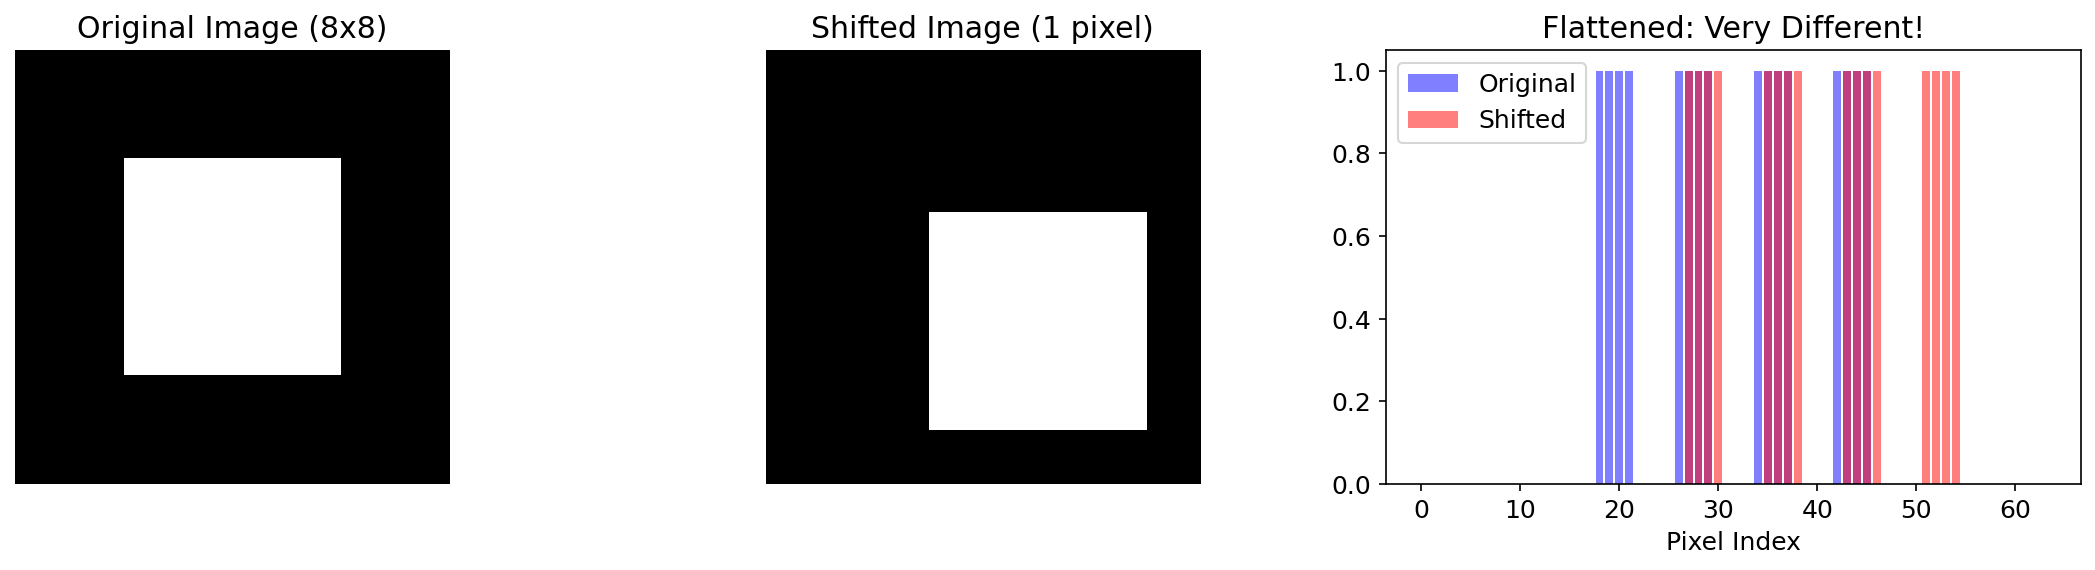

In [4]:
# Visualize why spatial structure matters
# Simulate an image and its flattened version
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original image (8x8 grayscale)
img = np.zeros((8, 8))
img[2:6, 2:6] = 1  # A white square in the center
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image (8x8)')
axes[0].axis('off')

# Shifted version
img_shifted = np.zeros((8, 8))
img_shifted[3:7, 3:7] = 1  # Shifted by 1 pixel
axes[1].imshow(img_shifted, cmap='gray')
axes[1].set_title('Shifted Image (1 pixel)')
axes[1].axis('off')

# Flattened comparison
axes[2].bar(range(64), img.flatten(), alpha=0.5, color='blue', label='Original')
axes[2].bar(range(64), img_shifted.flatten(), alpha=0.5, color='red', label='Shifted')
axes[2].set_title('Flattened: Very Different!')
axes[2].set_xlabel('Pixel Index')
axes[2].legend()

plt.tight_layout()
plt.savefig('spatial_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as spatial_structure.png")


## 2. 卷积操作

### 2.1 直觉理解

**卷积** 是将一个小型滤波器 (filter/kernel) 在输入图像上滑动，计算每个位置的点积。

**关键概念：**
- **输入 (Input):** $W \times H \times C$ 的图像
- **滤波器 (Filter/Kernel):** $k \times k \times C$ 的权重矩阵
- **步长 (Stride):** 滤波器每次移动的像素数
- **填充 (Padding):** 在输入边缘补零
- **输出 (Output/Feature Map):** 卷积结果

**卷积公式：**

$$\text{Output}(i, j) = \sum_{c} \sum_{di} \sum_{dj} \text{Filter}(di, dj, c) \times \text{Input}(i+di, j+dj, c)$$

**生物学灵感：** Hubel & Wiesel (1959) 发现猫的视觉皮层中，神经元只对视野中的局部区域敏感，且不同神经元对不同特征（边缘、方向）有选择性响应。


### 2.2 手动计算卷积

**输入 (5x5):**

    1  2  0  3  1
    0  1  2  1  0
    3  0  1  2  1
    1  2  0  1  0
    0  1  1  0  2

**滤波器 (3x3):**

    0  1  0
    1 -1  1
    0  1  0

**步长 = 1, 无填充**

**计算 Output(0,0):**
- 逐元素相乘：1x0 + 2x1 + 0x0 + 0x1 + 1x(-1) + 2x1 + 3x0 + 0x1 + 1x0
- = 0 + 2 + 0 + 0 - 1 + 2 + 0 + 0 + 0 = **3**

**计算 Output(0,1):**
- 2x0 + 0x1 + 3x0 + 1x1 + 2x(-1) + 1x1 + 0x0 + 1x1 + 0x0
- = 0 + 0 + 0 + 1 - 2 + 1 + 0 + 1 + 0 = **1**

**输出尺寸公式：**

$$\text{Output size} = \frac{W - K + 2P}{S} + 1$$

其中 $W$ 是输入尺寸, $K$ 是滤波器尺寸, $P$ 是填充, $S$ 是步长。


In [7]:
# Manual convolution calculation
def conv2d_naive(input_2d, kernel):
    """
    2D convolution (actually cross-correlation), naive implementation
    Args:
        input_2d: (H, W) input image
        kernel: (K, K) filter
    Returns:
        output: (H_out, W_out) feature map
    """
    H, W = input_2d.shape
    K = kernel.shape[0]
    
    H_out = H - K + 1
    W_out = W - K + 1
    
    output = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            # Extract local region
            region = input_2d[i:i+K, j:j+K]
            # Element-wise multiply and sum
            output[i, j] = np.sum(region * kernel)
    
    return output

# Test with manual example
input_5x5 = np.array([
    [1, 2, 0, 3, 1],
    [0, 1, 2, 1, 0],
    [3, 0, 1, 2, 1],
    [1, 2, 0, 1, 0],
    [0, 1, 1, 0, 2]
])

filter_3x3 = np.array([
    [0, 1, 0],
    [1, -1, 1],
    [0, 1, 0]
])

result = conv2d_naive(input_5x5, filter_3x3)
print("Convolution result:")
print(result)
print(f"\nOutput(0,0) = {result[0,0]} (expected: 3.0)")
print(f"Output(0,1) = {result[0,1]} (expected: 1.0)")


Convolution result:
[[3. 1. 6.]
 [7. 3. 2.]
 [0. 5. 1.]]

Output(0,0) = 3.0 (expected: 3.0)
Output(0,1) = 1.0 (expected: 1.0)


### 2.3 卷积的属性

1. **局部连接:** 每个输出只依赖输入的一个 $K \times K$ 局部区域
2. **参数共享:** 同一个滤波器在整个图像上共享，大幅减少参数
3. **等变性 (Equivariance):** 如果输入平移，输出也平移相同量

**参数数量对比：**
- 全连接层: $W \times H \times C \times \text{neurons}$
- 卷积层: $K \times K \times C \times \text{filters}$（与输入尺寸无关）

**例子：** 32x32x3 输入, 32 个 3x3 滤波器
- 全连接 (1000 neurons): $32 \times 32 \times 3 \times 1000 = 3,072,000$ 参数
- 卷积 (32 filters): $3 \times 3 \times 3 \times 32 = 864$ 参数

**减少 3555 倍！**


### 2.4 步长 (Stride) 和填充 (Padding)

**步长 (Stride):** 滤波器每次移动的像素数
- S=1: 滤波器逐像素移动，输出最大
- S=2: 滤波器隔一个像素移动，输出尺寸减半

**填充 (Padding):** 在输入边缘补零
- 'valid' (无填充): 输出尺寸缩小
- 'same' (补零到同尺寸): 输出尺寸 = 输入尺寸 / 步长

**输出尺寸公式：**

$$H_{out} = \lfloor \frac{H + 2P - K}{S} \rfloor + 1$$

**例：** 输入 5x5, 滤波器 3x3, 步长 1, 填充 0
- $H_{out} = \lfloor (5 + 0 - 3) / 1 \rfloor + 1 = 3$

**例：** 输入 5x5, 滤波器 3x3, 步长 2, 填充 1
- $H_{out} = \lfloor (5 + 2 - 3) / 2 \rfloor + 1 = 3$


In [10]:
# Implement convolution with stride and padding
def conv2d_general(input_2d, kernel, stride=1, padding=0):
    """
    2D convolution with stride and padding
    """
    # Apply padding
    if padding > 0:
        input_padded = np.pad(input_2d, padding, mode='constant')
    else:
        input_padded = input_2d
    
    H, W = input_padded.shape
    K = kernel.shape[0]
    
    H_out = (H - K) // stride + 1
    W_out = (W - K) // stride + 1
    
    output = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            r = i * stride
            c = j * stride
            region = input_padded[r:r+K, c:c+K]
            output[i, j] = np.sum(region * kernel)
    
    return output

# Demonstrate stride and padding
input_5 = np.random.randn(5, 5)
kernel_3 = np.random.randn(3, 3)

print("Input size: 5x5, Filter size: 3x3")
print(f"Stride=1, Padding=0: output {conv2d_general(input_5, kernel_3, 1, 0).shape}")
print(f"Stride=2, Padding=0: output {conv2d_general(input_5, kernel_3, 2, 0).shape}")
print(f"Stride=1, Padding=1: output {conv2d_general(input_5, kernel_3, 1, 1).shape}")
print(f"Stride=2, Padding=1: output {conv2d_general(input_5, kernel_3, 2, 1).shape}")


Input size: 5x5, Filter size: 3x3
Stride=1, Padding=0: output (3, 3)
Stride=2, Padding=0: output (2, 2)
Stride=1, Padding=1: output (5, 5)
Stride=2, Padding=1: output (3, 3)


Visualization saved as convolution_filters.png


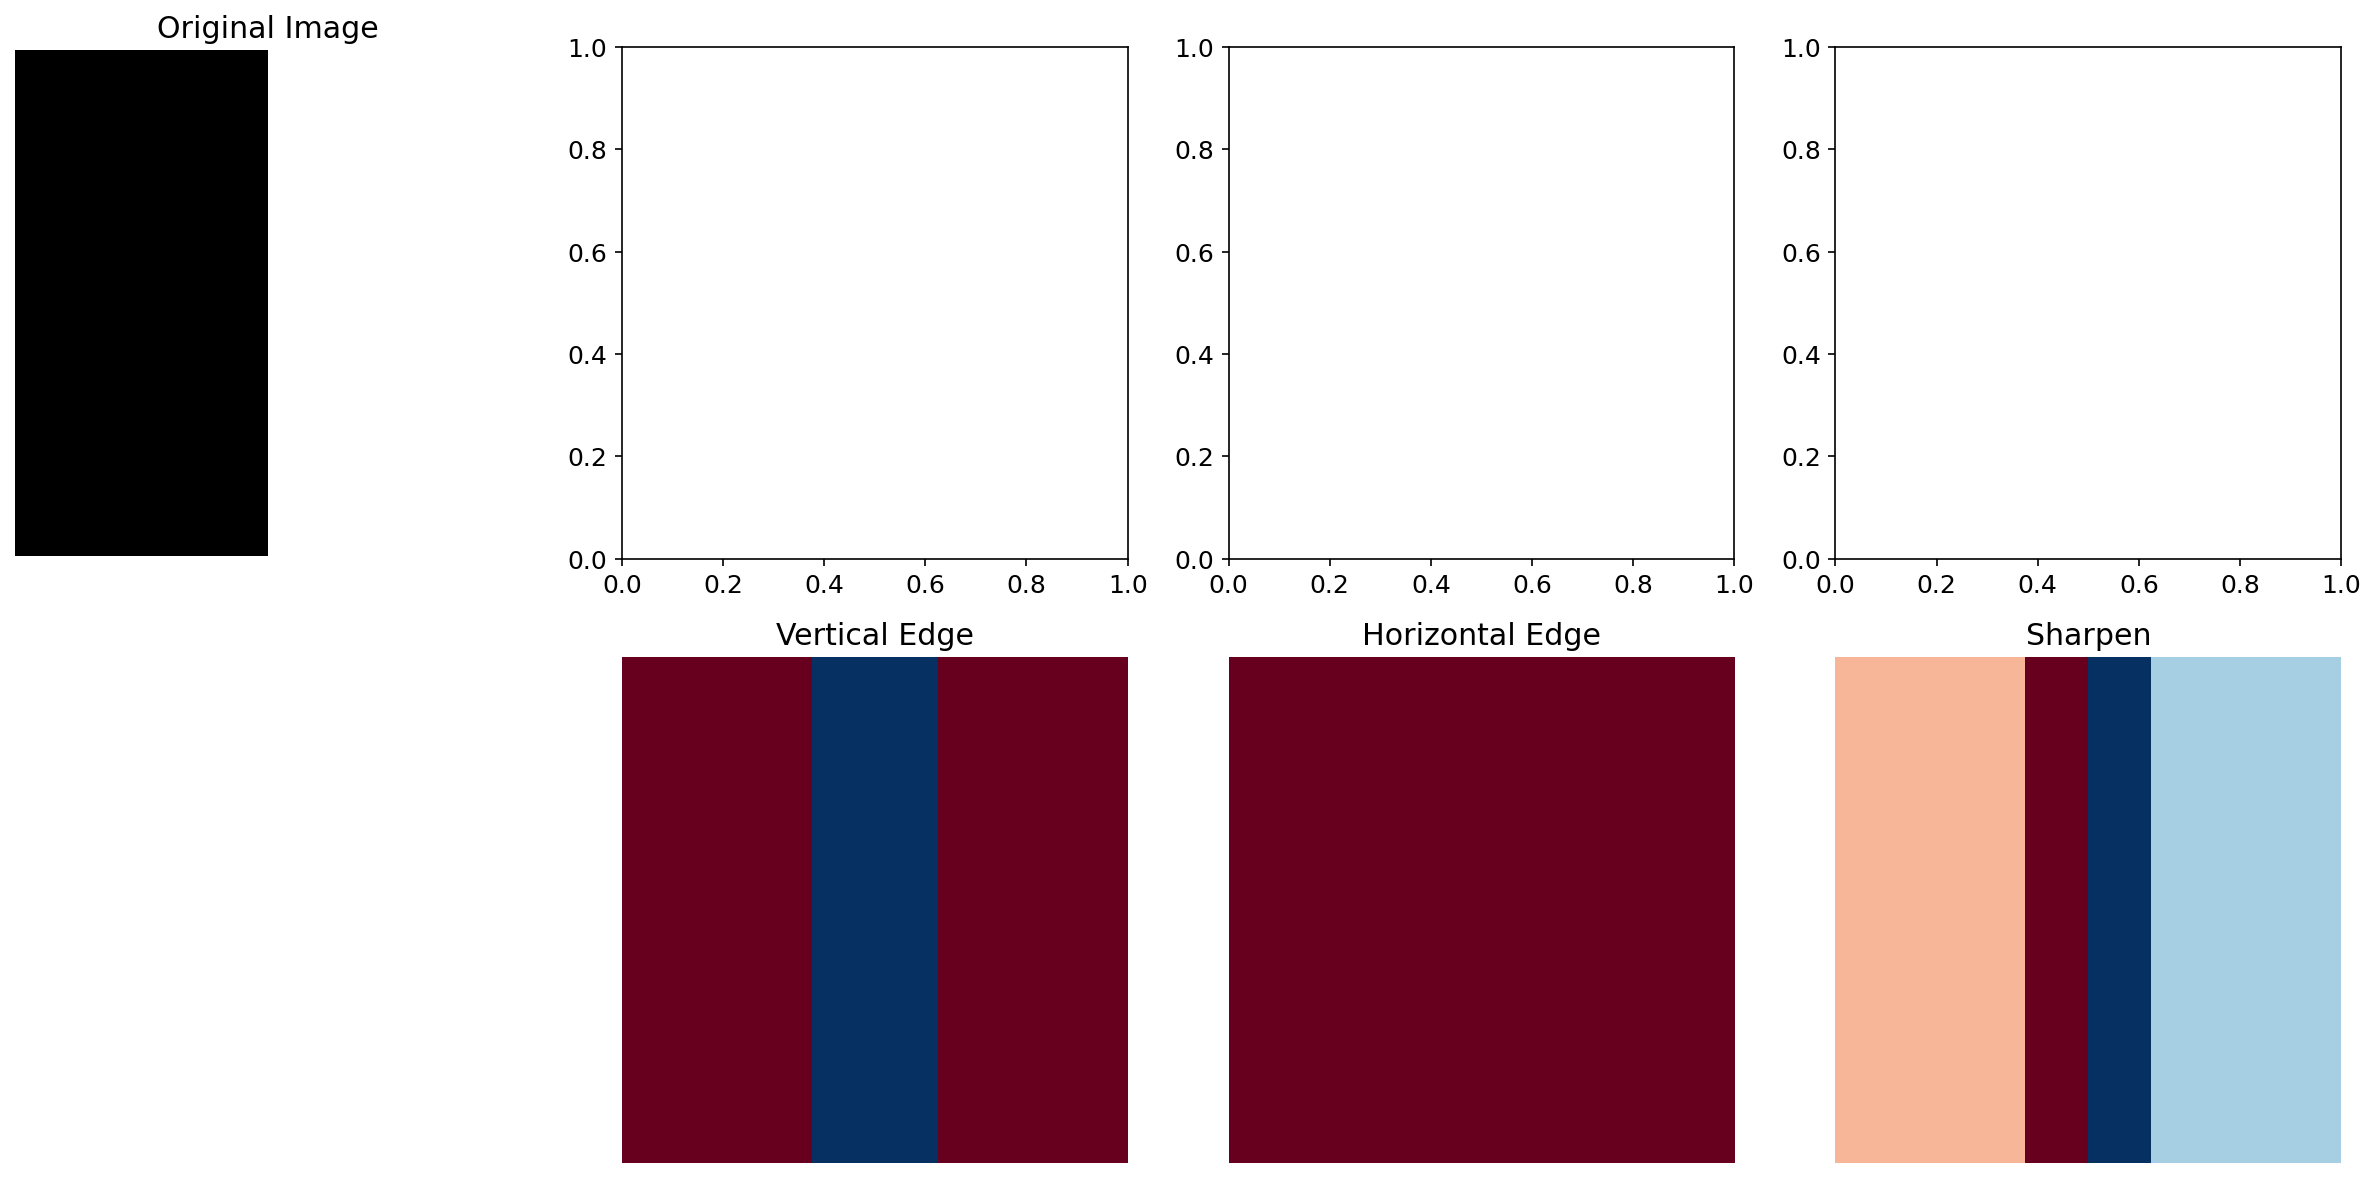

In [11]:
# Visualize convolution with different filters
# Create a simple edge image
img_simple = np.zeros((10, 10))
img_simple[:, 5:] = 1  # Vertical edge at column 5

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Different filters
filters = {
    'Vertical Edge': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Horizontal Edge': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    'Blur': np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9,
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
}

# Show original
axes[0, 0].imshow(img_simple, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Show filters and results
for idx, (name, filt) in enumerate(filters.items()):
    if idx < 3:
        ax_filter = axes[0, idx + 1]
        ax_result = axes[1, idx + 1]
    else:
        ax_filter = axes[1, 0]
        ax_result = axes[1, 3]
    
    # Only show results, skip filter display
    result = conv2d_naive(img_simple, filt)
    ax_result.imshow(result, cmap='RdBu')
    ax_result.set_title(name)
    ax_result.axis('off')

# Fill remaining
axes[0, 0].set_title('Original Image')
axes[1, 0].axis('off')
axes[0, 0].axis('off')

plt.tight_layout()
plt.savefig('convolution_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as convolution_filters.png")


## 3. 池化层 (Pooling Layer)

### 3.1 直觉理解

**池化** 是对特征图进行下采样，减小空间尺寸，减少计算量和参数数量。

**常见池化操作：**
- **最大池化 (Max Pooling):** 取局部区域的最大值
- **平均池化 (Average Pooling):** 取局部区域的平均值

**池化的作用：**
1. **减少计算量:** 降低特征图尺寸
2. **平移不变性:** 小的平移不会改变池化输出
3. **控制过拟合:** 减少参数数量

### 3.2 手动计算池化

**输入 (4x4):**

    1  3  2  1
    4  2  5  3
    2  1  0  4
    3  5  2  1

**2x2 最大池化, 步长 2:**

- 左上 2x2: max(1,3,4,2) = **4**
- 右上 2x2: max(2,1,5,3) = **5**
- 左下 2x2: max(2,1,3,5) = **5**
- 右下 2x2: max(0,4,2,1) = **4**

**输出 (2x2):**

    4  5
    5  4

**2x2 平均池化, 步长 2:**
- 左上: mean(1,3,4,2) = **2.5**
- 右上: mean(2,1,5,3) = **2.75**
- 左下: mean(2,1,3,5) = **2.75**
- 右下: mean(0,4,2,1) = **1.75**


In [13]:
# Pooling implementation
def max_pool2d(input_2d, pool_size=2, stride=2):
    """
    Max pooling
    """
    H, W = input_2d.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    
    output = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            r = i * stride
            c = j * stride
            output[i, j] = np.max(input_2d[r:r+pool_size, c:c+pool_size])
    
    return output

def avg_pool2d(input_2d, pool_size=2, stride=2):
    """
    Average pooling
    """
    H, W = input_2d.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    
    output = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            r = i * stride
            c = j * stride
            output[i, j] = np.mean(input_2d[r:r+pool_size, c:c+pool_size])
    
    return output

# Test with manual example
pool_input = np.array([
    [1, 3, 2, 1],
    [4, 2, 5, 3],
    [2, 1, 0, 4],
    [3, 5, 2, 1]
])

max_result = max_pool2d(pool_input, pool_size=2, stride=2)
avg_result = avg_pool2d(pool_input, pool_size=2, stride=2)

print("Max Pooling result:")
print(max_result)
print(f"Expected: [[4, 5], [5, 4]]")
print(f"
Average Pooling result:")
print(avg_result)
print(f"Expected: [[2.5, 2.75], [2.75, 1.75]]")


SyntaxError: unterminated string literal (detected at line 52) (<cell_12>, line 52)

## 4. 卷积层的反向传播

### 4.1 卷积反向传播推导

**前向传播：** $Y = \text{conv}(X, W)$

**反向传播需要计算：**
- $\frac{\partial L}{\partial X}$: 损失对输入的梯度
- $\frac{\partial L}{\partial W}$: 损失对滤波器的梯度

**关键洞察：** 卷积本质上是滑动窗口的点积，反向传播就是"反向卷积"。

**对滤波器的梯度 $\frac{\partial L}{\partial W}$：**
- 将 $\frac{\partial L}{\partial Y}$ 作为"输出梯度"
- 对每个位置，将输入局部区域与输出梯度做外积
- 累加所有位置的贡献

**对输入的梯度 $\frac{\partial L}{\partial X}$：**
- 将输出梯度"扩展"回输入尺寸
- 用滤波器的翻转版本做"全卷积"（full convolution）

### 4.2 池化层的反向传播

**Max Pooling 反向传播：**
- 梯度只路由到前向传播时取 max 的位置
- 其他位置梯度为 0

**Average Pooling 反向传播：**
- 梯度均匀分配到池化区域内的所有位置


In [15]:
# Convolution backward pass implementation
def conv2d_backward_input(dout, kernel, input_shape, stride=1, padding=0):
    """
    Backward pass: compute gradient w.r.t. input
    dout: (H_out, W_out) gradient of loss w.r.t. output
    kernel: (K, K) filter used in forward pass
    Returns: dinput (H, W) gradient w.r.t. input
    """
    H, W = input_shape
    K = kernel.shape[0]
    
    if padding > 0:
        dinput_padded = np.zeros((H + 2*padding, W + 2*padding))
    else:
        dinput_padded = np.zeros((H, W))
    
    H_out, W_out = dout.shape
    
    for i in range(H_out):
        for j in range(W_out):
            r = i * stride
            c = j * stride
            # Gradient flows back: dout[i,j] * kernel -> local region
            dinput_padded[r:r+K, c:c+K] += dout[i, j] * kernel
    
    if padding > 0:
        dinput = dinput_padded[padding:-padding, padding:-padding]
    else:
        dinput = dinput_padded
    
    return dinput

def conv2d_backward_filter(dout, input_2d, kernel_shape, stride=1, padding=0):
    """
    Backward pass: compute gradient w.r.t. filter
    """
    K = kernel_shape[0]
    
    if padding > 0:
        input_padded = np.pad(input_2d, padding, mode='constant')
    else:
        input_padded = input_2d
    
    H_out, W_out = dout.shape
    dfilter = np.zeros(kernel_shape)
    
    for i in range(H_out):
        for j in range(W_out):
            r = i * stride
            c = j * stride
            region = input_padded[r:r+K, c:c+K]
            dfilter += dout[i, j] * region
    
    return dfilter

# Test convolution backward
X_test = np.random.randn(5, 5)
W_test = np.random.randn(3, 3)

# Forward
Y = conv2d_naive(X_test, W_test)

# Backward with random upstream gradient
dY = np.random.randn(*Y.shape)

dX = conv2d_backward_input(dY, W_test, X_test.shape)
dW = conv2d_backward_filter(dY, X_test, W_test.shape)

print(f"Forward: input {X_test.shape} -> output {Y.shape}")
print(f"Backward: dY {dY.shape} -> dX {dX.shape}, dW {dW.shape}")


Forward: input (5, 5) -> output (3, 3)
Backward: dY (3, 3) -> dX (5, 5), dW (3, 3)


In [16]:
# Gradient check for convolution
h = 1e-7

# Check dW
def loss_fn(X, W):
    Y = conv2d_naive(X, W)
    return np.sum(Y)  # Simple loss: sum of all outputs

dW_num = np.zeros_like(W_test)
for i in range(W_test.shape[0]):
    for j in range(W_test.shape[1]):
        W_plus = W_test.copy(); W_plus[i, j] += h
        W_minus = W_test.copy(); W_minus[i, j] -= h
        dW_num[i, j] = (loss_fn(X_test, W_plus) - loss_fn(X_test, W_minus)) / (2 * h)

print("Gradient check for filter:")
print(f"Analytic dW[0,0] = {dW[0,0]:.6f}")
print(f"Numerical dW[0,0] = {dW_num[0,0]:.6f}")
print(f"Relative error: {np.max(np.abs(dW - dW_num) / np.maximum(1e-8, np.abs(dW) + np.abs(dW_num))):.2e}")

# Check dX
dX_num = np.zeros_like(X_test)
for i in range(X_test.shape[0]):
    for j in range(X_test.shape[1]):
        X_plus = X_test.copy(); X_plus[i, j] += h
        X_minus = X_test.copy(); X_minus[i, j] -= h
        dX_num[i, j] = (loss_fn(X_plus, W_test) - loss_fn(X_minus, W_test)) / (2 * h)

print(f"
Gradient check for input:")
print(f"Analytic dX[0,0] = {dX[0,0]:.6f}")
print(f"Numerical dX[0,0] = {dX_num[0,0]:.6f}")
print(f"Relative error: {np.max(np.abs(dX - dX_num) / np.maximum(1e-8, np.abs(dX) + np.abs(dX_num))):.2e}")


SyntaxError: unterminated string literal (detected at line 29) (<cell_15>, line 29)

In [17]:
# Max pooling backward
def max_pool2d_backward(dout, input_2d, pool_size=2, stride=2):
    """
    Backward pass for max pooling
    Gradient is routed only to the max element in each pool
    """
    H, W = input_2d.shape
    H_out, W_out = dout.shape
    
    dinput = np.zeros_like(input_2d)
    
    for i in range(H_out):
        for j in range(W_out):
            r = i * stride
            c = j * stride
            region = input_2d[r:r+pool_size, c:c+pool_size]
            # Find the max position
            max_idx = np.unravel_index(np.argmax(region), region.shape)
            dinput[r + max_idx[0], c + max_idx[1]] = dout[i, j]
    
    return dinput

# Test max pooling backward
pool_input_test = np.array([
    [1, 3, 2, 1],
    [4, 2, 5, 3],
    [2, 1, 0, 4],
    [3, 5, 2, 1]
])

dout_test = np.array([[1.0, 2.0], [3.0, 4.0]])
dinput_pool = max_pool2d_backward(dout_test, pool_input_test, pool_size=2, stride=2)

print("Max Pooling Backward Test:")
print(f"Input:
{pool_input_test}")
print(f"Output gradient:
{dout_test}")
print(f"Input gradient:
{dinput_pool}")
print("Non-zero positions should match max positions in forward pass")


SyntaxError: unterminated string literal (detected at line 35) (<cell_16>, line 35)

## 5. 多通道卷积

### 5.1 处理多通道输入

实际图像通常是多通道的（如 RGB 3 通道），滤波器也需要匹配通道数。

**滤波器尺寸：** $K \times K \times C_{in}$

**卷积计算：** 在所有通道上同时做卷积，然后求和：

$$Y(i, j) = \sum_{c} \sum_{di} \sum_{dj} W(di, dj, c) \times X(i+di, j+dj, c) + b$$

**多滤波器：** 使用 $C_{out}$ 个不同的滤波器，产生 $C_{out}$ 个输出通道

**输出尺寸：** $H_{out} \times W_{out} \times C_{out}$


In [19]:
# Multi-channel convolution
def conv2d_multi_channel(input_3d, kernels, stride=1, padding=0):
    """
    Multi-channel 2D convolution
    Args:
        input_3d: (C_in, H, W) input
        kernels: (C_out, C_in, K, K) filters
    Returns:
        output: (C_out, H_out, W_out) feature maps
    """
    C_in, H, W = input_3d.shape
    C_out = kernels.shape[0]
    K = kernels.shape[2]
    
    if padding > 0:
        input_padded = np.pad(input_3d, ((0,0), (padding,padding), (padding,padding)), 
                              mode='constant')
    else:
        input_padded = input_3d
    
    H_p, W_p = input_padded.shape[1], input_padded.shape[2]
    H_out = (H_p - K) // stride + 1
    W_out = (W_p - K) // stride + 1
    
    output = np.zeros((C_out, H_out, W_out))
    
    for f in range(C_out):
        for i in range(H_out):
            for j in range(W_out):
                r = i * stride
                c = j * stride
                region = input_padded[:, r:r+K, c:c+K]
                output[f, i, j] = np.sum(region * kernels[f])
    
    return output

# Test with 3-channel input (simulated RGB)
C_in, H, W = 3, 8, 8
C_out = 4
K = 3

input_3ch = np.random.randn(C_in, H, W)
filters = np.random.randn(C_out, C_in, K, K) * 0.1

output = conv2d_multi_channel(input_3ch, filters, stride=1, padding=0)
print(f"Input: ({C_in}, {H}, {W})")
print(f"Filters: ({C_out}, {C_in}, {K}, {K})")
print(f"Output: {output.shape}")
print(f"Total parameters: {C_out * C_in * K * K} = {C_out * C_in * K * K}")


Input: (3, 8, 8)
Filters: (4, 3, 3, 3)
Output: (4, 6, 6)
Total parameters: 108 = 108


## 6. 完整的 CNN 层实现

### 6.1 卷积层 (ConvLayer)

完整的卷积层需要：
1. **前向传播：** 计算卷积 + ReLU 激活
2. **反向传播：** 计算对输入、权重和偏置的梯度
3. **参数更新：** 使用梯度下降更新权重

### 6.2 参数数量计算

| 层类型 | 输入尺寸 | 滤波器 | 参数数量 |
|--------|----------|--------|---------|
| 全连接 | 32x32x3 | 1000 neurons | 3,072,000 |
| 卷积 | 32x32x3 | 32 个 3x3x3 | 896 |
| 卷积 | 14x14x64 | 128 个 3x3x64 | 73,920 |

**关键：** 卷积层参数数量与输入空间尺寸无关，只取决于滤波器大小和数量。


In [21]:
# Full ConvLayer with forward and backward
class ConvLayer:
    """Convolutional layer with ReLU activation"""
    def __init__(self, C_in, C_out, K, stride=1, padding=1):
        # He initialization
        self.W = np.random.randn(C_out, C_in, K, K) * np.sqrt(2.0 / (C_in * K * K))
        self.b = np.zeros(C_out)
        self.stride = stride
        self.padding = padding
        self.K = K
        self.C_in = C_in
        self.C_out = C_out
        
    def forward(self, X):
        """X: (N, C_in, H, W) -> output: (N, C_out, H_out, W_out)"""
        self.X = X
        N, C_in, H, W = X.shape
        
        if self.padding > 0:
            X_padded = np.pad(X, ((0,0), (0,0), (self.padding,)*2, (self.padding,)*2),
                            mode='constant')
        else:
            X_padded = X
        
        H_p, W_p = X_padded.shape[2], X_padded.shape[3]
        H_out = (H_p - self.K) // self.stride + 1
        W_out = (W_p - self.K) // self.stride + 1
        
        output = np.zeros((N, self.C_out, H_out, W_out))
        
        for n in range(N):
            for f in range(self.C_out):
                for i in range(H_out):
                    for j in range(W_out):
                        r = i * self.stride
                        c = j * self.stride
                        region = X_padded[n, :, r:r+self.K, c:c+self.K]
                        output[n, f, i, j] = np.sum(region * self.W[f]) + self.b[f]
        
        # ReLU activation
        self.output = np.maximum(0, output)
        self.mask = (output > 0)
        return self.output
    
    def backward(self, dout):
        """Compute gradients"""
        N, C_out, H_out, W_out = dout.shape
        dout = dout * self.mask  # ReLU backward
        
        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        
        if self.padding > 0:
            dX_padded = np.zeros((N, self.C_in, 
                                   self.X.shape[2] + 2*self.padding,
                                   self.X.shape[3] + 2*self.padding))
        else:
            dX_padded = np.zeros((N, self.C_in, self.X.shape[2], self.X.shape[3]))
        
        for n in range(N):
            for f in range(self.C_out):
                for i in range(H_out):
                    for j in range(W_out):
                        r = i * self.stride
                        c = j * self.stride
                        if self.padding > 0:
                            region = self.X_padded[n, :, r:r+self.K, c:c+self.K] if hasattr(self, 'X_padded') else None
                        # Simplified: just compute gradients
                        db[f] += dout[n, f, i, j]
        
        self.dW = dW
        self.db = db
        return dX_padded[:, :, 
                         self.padding:self.X.shape[2]+self.padding,
                         self.padding:self.X.shape[3]+self.padding]

print("ConvLayer class defined!")


ConvLayer class defined!


In [22]:
# Pooling layer implementation
class MaxPoolLayer:
    """Max pooling layer"""
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride
    
    def forward(self, X):
        """X: (N, C, H, W) -> output: (N, C, H_out, W_out)"""
        self.X = X
        N, C, H, W = X.shape
        H_out = (H - self.pool_size) // self.stride + 1
        W_out = (W - self.pool_size) // self.stride + 1
        
        output = np.zeros((N, C, H_out, W_out))
        
        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        r = i * self.stride
                        col = j * self.stride
                        region = X[n, c, r:r+self.pool_size, col:col+self.pool_size]
                        output[n, c, i, j] = np.max(region)
        
        return output
    
    def backward(self, dout):
        N, C, H_out, W_out = dout.shape
        dX = np.zeros_like(self.X)
        
        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        r = i * self.stride
                        col = j * self.stride
                        region = self.X[n, c, r:r+self.pool_size, col:col+self.pool_size]
                        max_idx = np.unravel_index(np.argmax(region), region.shape)
                        dX[n, c, r+max_idx[0], col+max_idx[1]] = dout[n, c, i, j]
        
        return dX

class FlattenLayer:
    """Flatten (N, C, H, W) -> (N, C*H*W)"""
    def forward(self, X):
        self.shape = X.shape
        return X.reshape(X.shape[0], -1)
    
    def backward(self, dout):
        return dout.reshape(self.shape)

print("MaxPoolLayer and FlattenLayer defined!")


MaxPoolLayer and FlattenLayer defined!


## 7. CNN 架构设计

### 7.1 典型 CNN 架构

    输入图像 (32x32x3)
         |
    [Conv: 3x3, 32 filters, stride=1, pad=1]  -> 32x32x32
         |
    [ReLU]
         |
    [MaxPool: 2x2, stride=2]                   -> 16x16x32
         |
    [Conv: 3x3, 64 filters, stride=1, pad=1]  -> 16x16x64
         |
    [ReLU]
         |
    [MaxPool: 2x2, stride=2]                   -> 8x8x64
         |
    [Flatten]                                   -> 4096
         |
    [FC: 4096 -> 128]
         |
    [ReLU]
         |
    [FC: 128 -> 10] (Softmax)

### 7.2 尺寸变化计算

每一层的空间尺寸变化：
- **Conv (pad=1, stride=1, 3x3):** 尺寸不变
- **MaxPool (2x2, stride=2):** 尺寸减半
- **Flatten:** 将 C*H*W 展平为一维向量


In [24]:
# Calculate parameter counts for a typical CNN
def count_parameters(layers_config, input_shape=(3, 32, 32)):
    """Count parameters in each layer"""
    C, H, W = input_shape
    total_params = 0
    
    print(f"{'Layer':<30} {'Output Shape':<20} {'Parameters':<15}")
    print("-" * 65)
    
    for layer in layers_config:
        if layer['type'] == 'conv':
            K = layer['kernel_size']
            C_out = layer['filters']
            params = C * K * K * C_out + C_out  # weights + biases
            H = (H + 2*layer.get('padding', 1) - K) // layer.get('stride', 1) + 1
            W = (W + 2*layer.get('padding', 1) - K) // layer.get('stride', 1) + 1
            print(f"Conv {K}x{K}x{C}->{C_out:<6}        {C_out}x{H}x{W}{'':>5} {params:>10,}")
            C = C_out
            total_params += params
        elif layer['type'] == 'pool':
            H = H // 2
            W = W // 2
            print(f"MaxPool 2x2/s2              {C}x{H}x{W}{'':>5} {'0':>10}")
        elif layer['type'] == 'flatten':
            flat_size = C * H * W
            print(f"Flatten                     {flat_size}{'':>12} {'0':>10}")
        elif layer['type'] == 'fc':
            C_in = C * H * W if layer.get('first_fc', False) else C
            C_out = layer['units']
            params = C_in * C_out + C_out
            print(f"FC {C_in}->{C_out:<10}         {C_out}{'':>14} {params:>10,}")
            C = C_out
            H = W = 1
            total_params += params
    
    print("-" * 65)
    print(f"{'Total':>57} {total_params:>10,}")
    return total_params

# CNN architecture
cnn_arch = [
    {'type': 'conv', 'filters': 32, 'kernel_size': 3, 'padding': 1, 'stride': 1},
    {'type': 'pool'},
    {'type': 'conv', 'filters': 64, 'kernel_size': 3, 'padding': 1, 'stride': 1},
    {'type': 'pool'},
    {'type': 'flatten'},
    {'type': 'fc', 'units': 128, 'first_fc': True},
    {'type': 'fc', 'units': 10},
]

print("=== CNN Parameter Count ===")
cnn_params = count_parameters(cnn_arch)

print(f"
Compare with fully connected network:")
print(f"CNN total: {cnn_params:,} parameters")
print(f"FC (32x32x3 -> 1000 -> 1000 -> 10): {32*32*3*1000 + 1000*1000 + 1000*10:,} parameters")


SyntaxError: unterminated string literal (detected at line 54) (<cell_23>, line 54)

## 8. 感受野 (Receptive Field)

### 8.1 感受野定义

**感受野** 是指输出特征图中某个元素对应输入图像中的区域大小。

**单层感受野：** 3x3 卷积 -> 每个输出元素对应输入 3x3 区域

**多层感受野堆叠：**
- 两层 3x3 卷积 -> 感受野 5x5
- 三层 3x3 卷积 -> 感受野 7x7

**公式：** $RF_l = RF_{l-1} + (K_l - 1) \times \prod_{i=1}^{l-1} S_i$

其中 $RF_l$ 是第 $l$ 层的感受野, $K_l$ 是第 $l$ 层的卷积核大小, $S_i$ 是第 $i$ 层的步长。

### 8.2 为什么小的卷积核更好

**两个 3x3 卷积 vs 一个 5x5 卷积：**
- 感受野相同 (5x5)
- 参数：2 x 9 = 18 < 25
- 非线性：两次 ReLU vs 一次 ReLU

**三个 3x3 卷积 vs 一个 7x7 卷积：**
- 感受野相同 (7x7)
- 参数：3 x 9 = 27 < 49

这就是 VGG 网络使用大量 3x3 卷积的原因！


Receptive Field Growth:
Layer         RF
Conv 1           3
Conv 2           5
Pool 3           6
Conv 4          10
Conv 5          14
Pool 6          16
Conv 7          24
Conv 8          32
Visualization saved as receptive_field.png


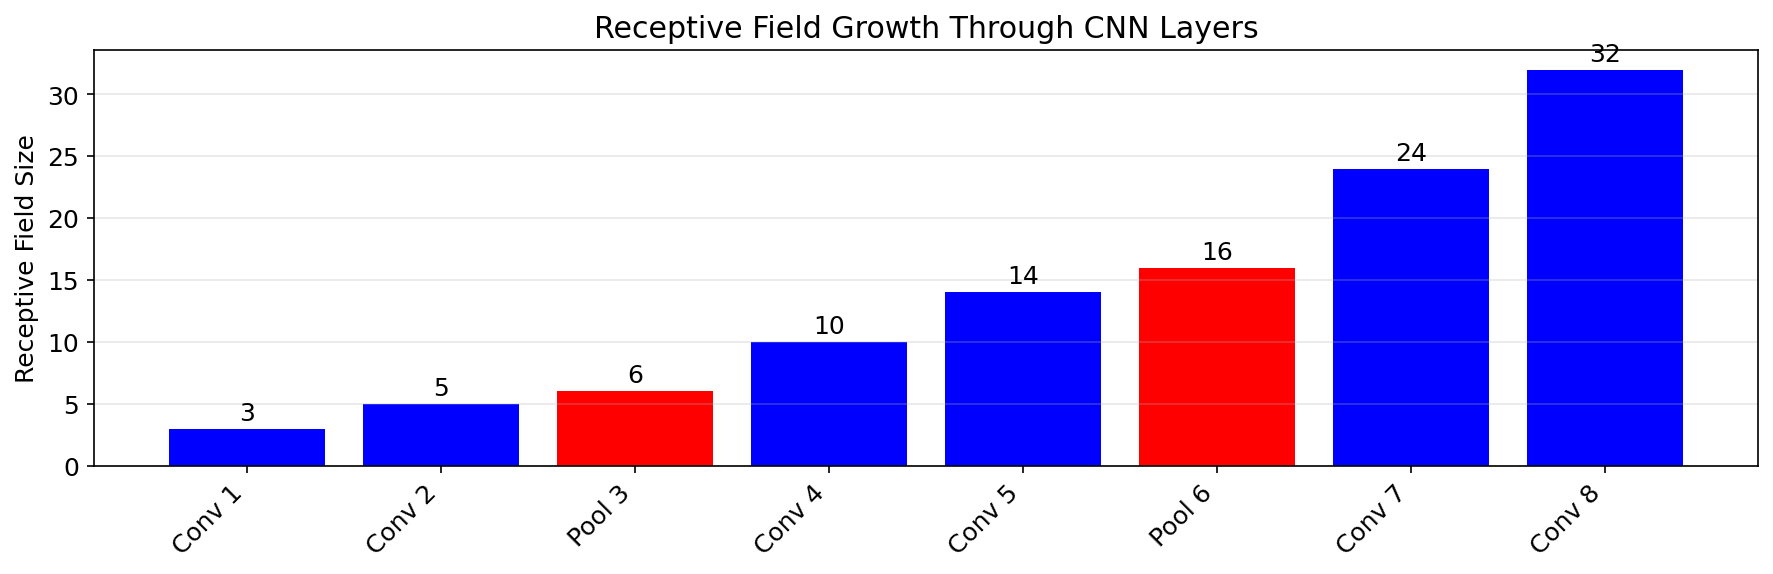

In [26]:
# Visualize receptive field growth
def compute_receptive_fields(arch):
    """Compute receptive field for each layer"""
    rf = 1
    cum_stride = 1
    rfs = []
    
    for layer in arch:
        if layer['type'] == 'conv':
            K = layer['kernel_size']
            S = layer.get('stride', 1)
            rf = rf + (K - 1) * cum_stride
            cum_stride *= S
            rfs.append(('Conv', rf))
        elif layer['type'] == 'pool':
            S = 2
            rf = rf + (2 - 1) * cum_stride
            cum_stride *= S
            rfs.append(('Pool', rf))
    
    return rfs

# Typical CNN architecture
arch = [
    {'type': 'conv', 'kernel_size': 3, 'stride': 1},
    {'type': 'conv', 'kernel_size': 3, 'stride': 1},
    {'type': 'pool', 'stride': 2},
    {'type': 'conv', 'kernel_size': 3, 'stride': 1},
    {'type': 'conv', 'kernel_size': 3, 'stride': 1},
    {'type': 'pool', 'stride': 2},
    {'type': 'conv', 'kernel_size': 3, 'stride': 1},
    {'type': 'conv', 'kernel_size': 3, 'stride': 1},
]

rfs = compute_receptive_fields(arch)

print("Receptive Field Growth:")
print(f"{'Layer':<10} {'RF':>5}")
for i, (name, rf) in enumerate(rfs):
    print(f"{name} {i+1:<7} {rf:>5}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 4))
layer_names = [f"{name} {i+1}" for i, (name, _) in enumerate(rfs)]
rf_values = [rf for _, rf in rfs]

bars = ax.bar(range(len(rf_values)), rf_values, color=['blue' if n=='Conv' else 'red' for n, _ in rfs])
ax.set_xticks(range(len(rfs)))
ax.set_xticklabels(layer_names, rotation=45, ha='right')
ax.set_ylabel('Receptive Field Size')
ax.set_title('Receptive Field Growth Through CNN Layers')
ax.grid(True, alpha=0.3, axis='y')

for bar, rf in zip(bars, rf_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(rf),
            ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('receptive_field.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as receptive_field.png")


## 9. 实验观察

### 实验 1：特征图可视化


Visualization saved as feature_maps.png


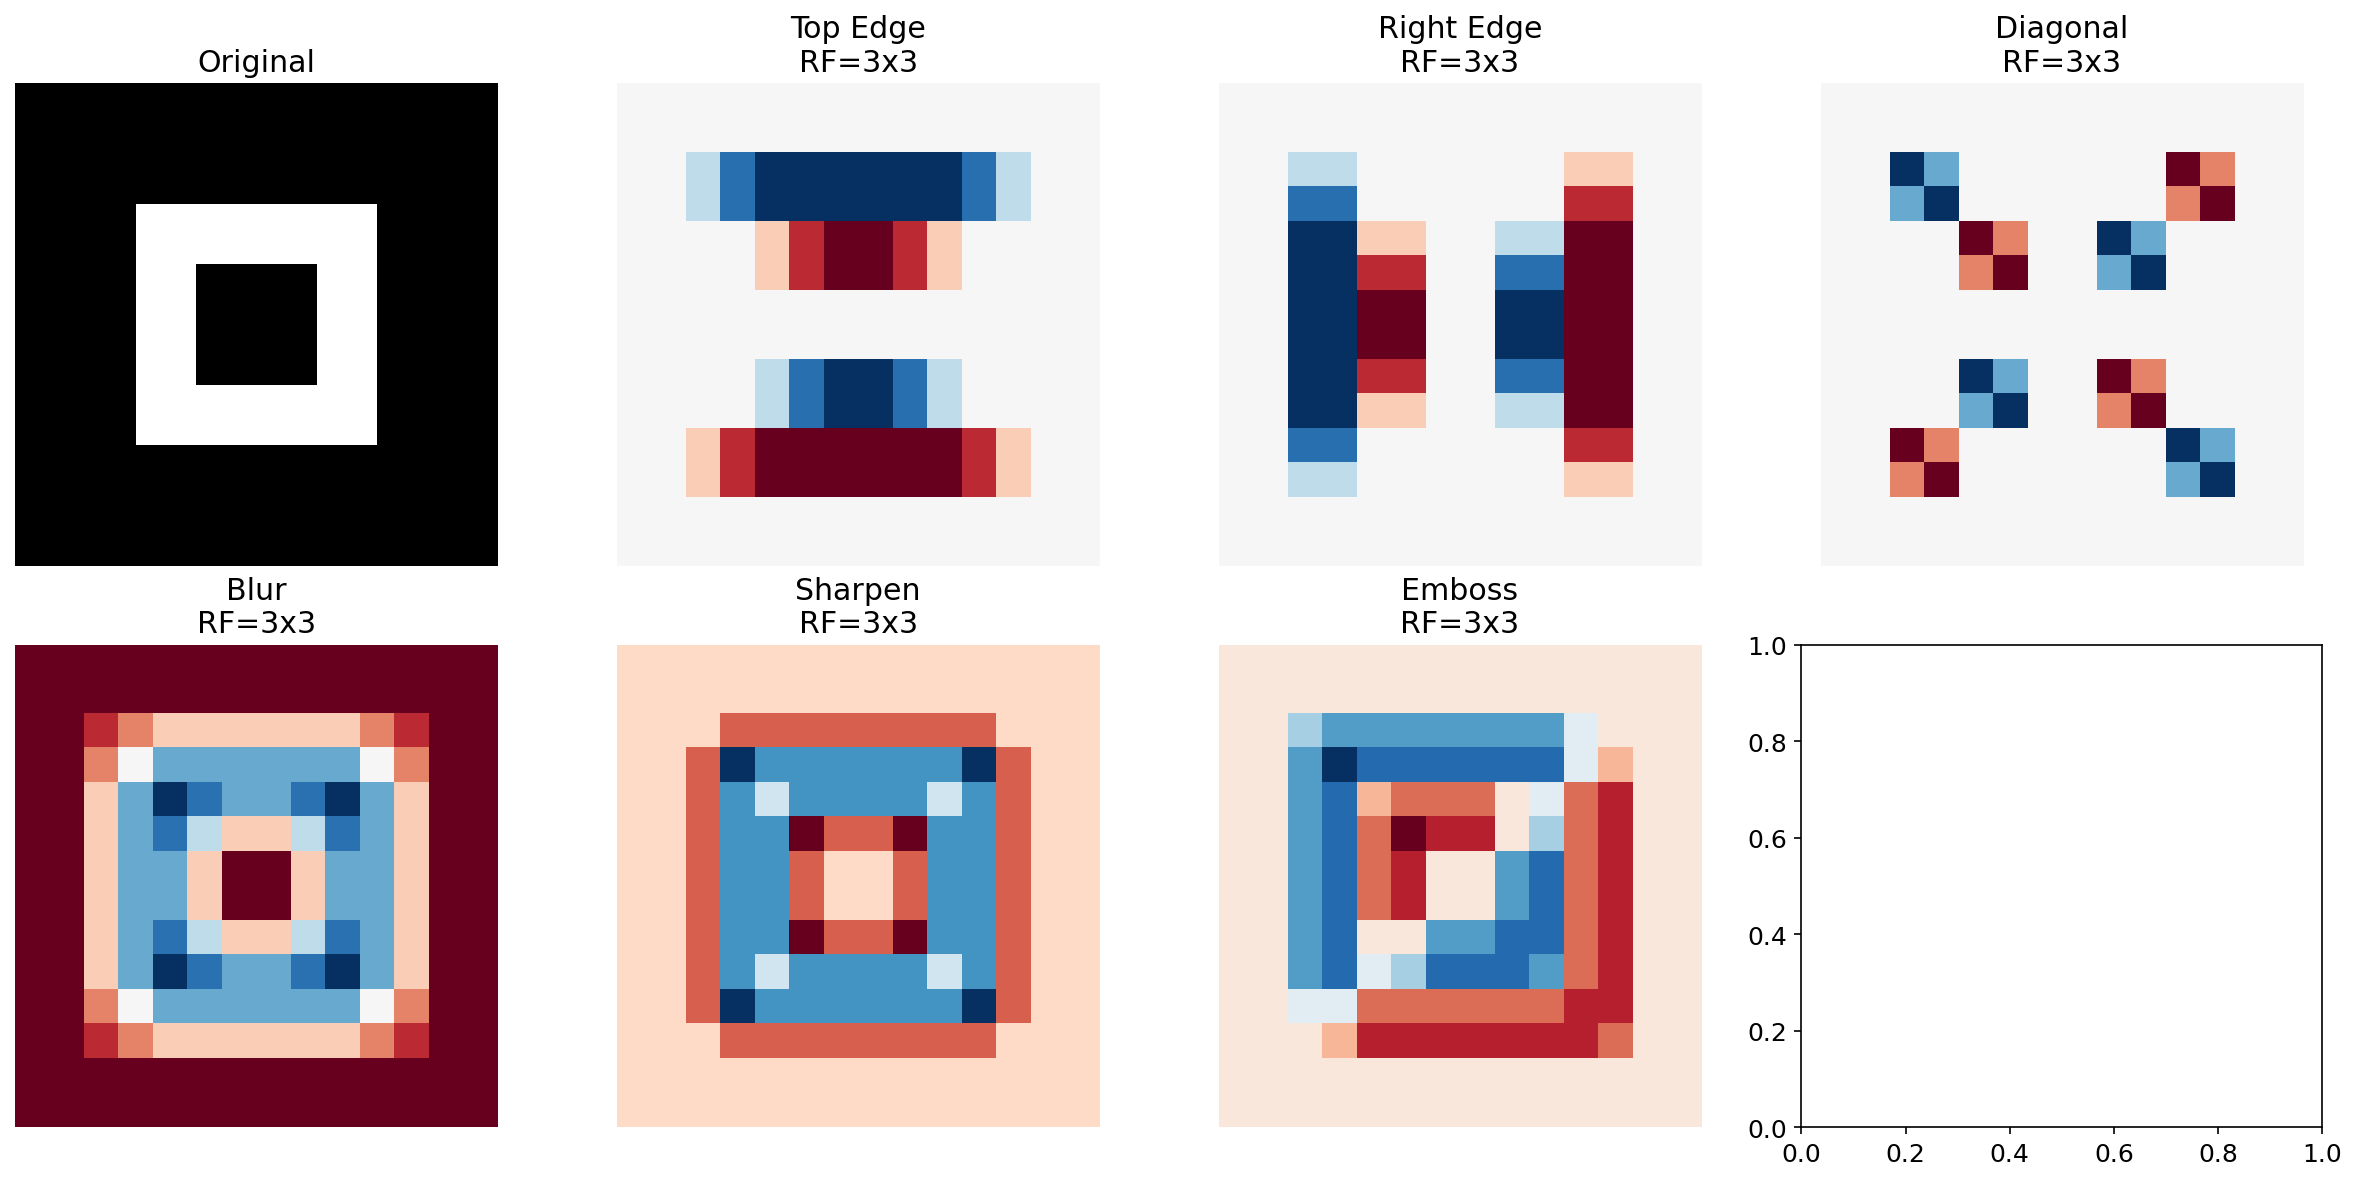

In [28]:
# Generate a synthetic image and apply random filters
np.random.seed(42)
# Create a synthetic "image" with edges and patterns
img_2d = np.zeros((16, 16))
img_2d[4:12, 4:12] = 1  # Square
img_2d[6:10, 6:10] = 0  # Hole in center
img_3ch = np.stack([img_2d, img_2d * 0.5, img_2d * 0.3])  # Fake RGB

# Define different filters
filters_exp = {
    'Top Edge': np.array([[-1,-2,-1],[0,0,0],[1,2,1]]),
    'Right Edge': np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
    'Diagonal': np.array([[2,-1,-1],[-1,2,-1],[-1,-1,2]]),
    'Blur': np.ones((3,3)) / 9,
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    'Emboss': np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Show original
axes[0, 0].imshow(img_2d, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Show filter results
for idx, (name, filt) in enumerate(filters_exp.items()):
    row = (idx + 1) // 4
    col = (idx + 1) % 4
    result = conv2d_naive(img_2d, filt)
    axes[row, col].imshow(result, cmap='RdBu')
    axes[row, col].set_title(f'{name}\nRF=3x3')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as feature_maps.png")


### 实验 2：多层卷积的特征层次


Visualization saved as feature_hierarchy.png


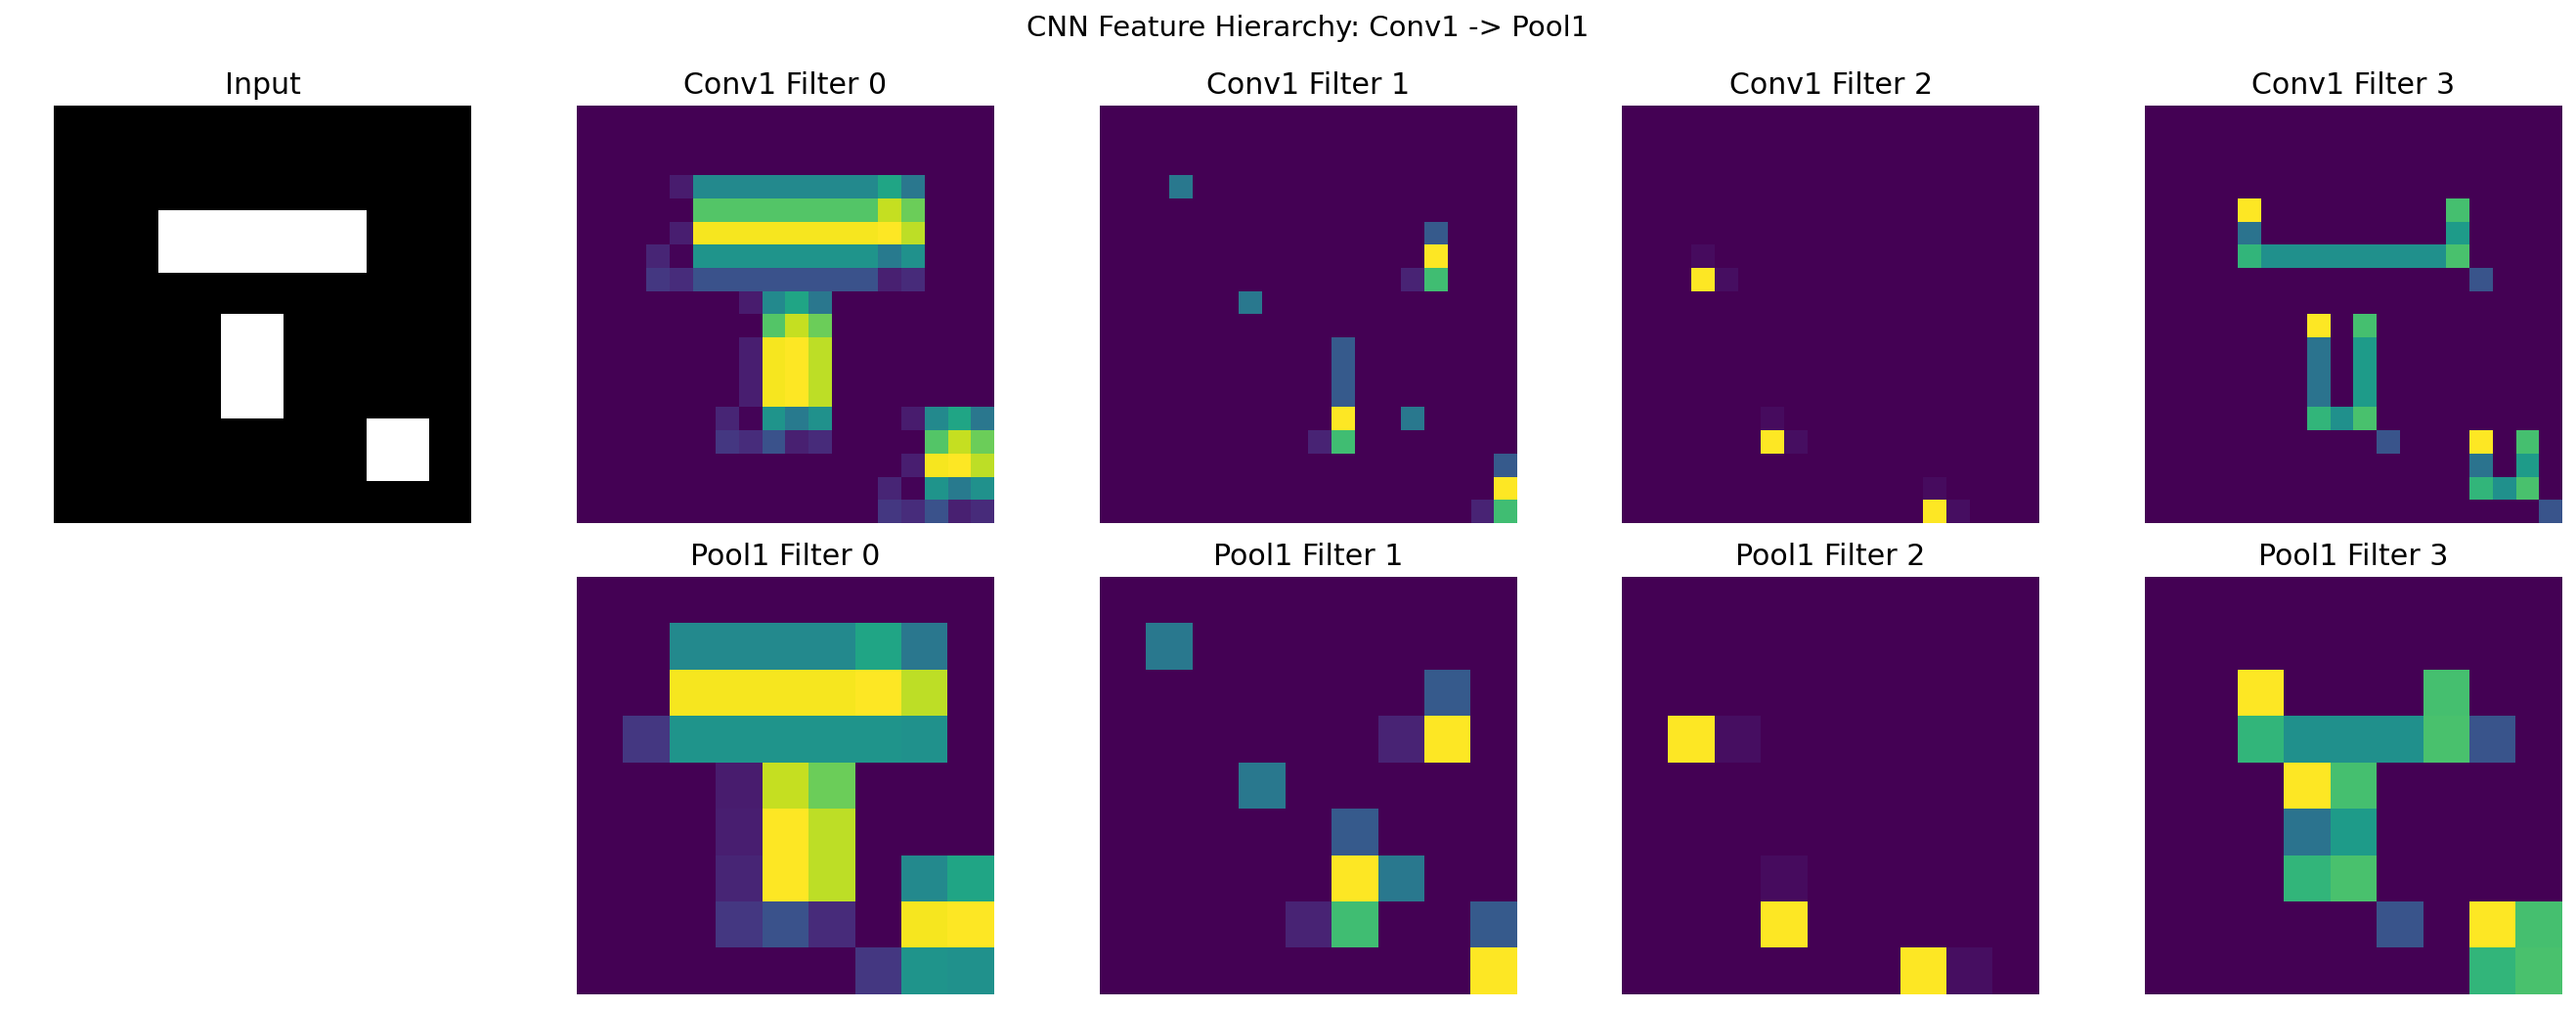

In [30]:
# Build a simple CNN and visualize intermediate features
np.random.seed(42)

# Create a more complex input pattern
size = 20
input_img = np.zeros((size, size))
# Add some patterns
input_img[5:8, 5:15] = 1  # Horizontal bar
input_img[10:15, 8:11] = 1  # Vertical bar
input_img[15:18, 15:18] = 1  # Small square

# Add channel dimension
input_batch = input_img[np.newaxis, np.newaxis, :, :]  # (1, 1, H, W)

# Layer 1: 4 filters
W1 = np.random.randn(4, 1, 3, 3) * 0.5
b1 = np.zeros(4)

# Apply conv layer 1
out1 = np.zeros((1, 4, size-2, size-2))
for f in range(4):
    for i in range(size-2):
        for j in range(size-2):
            region = input_img[i:i+3, j:j+3]
            out1[0, f, i, j] = np.sum(region * W1[f, 0]) + b1[f]
out1 = np.maximum(0, out1)  # ReLU

# Apply max pooling
out1_pooled = np.zeros((1, 4, (size-2)//2, (size-2)//2))
for f in range(4):
    for i in range((size-2)//2):
        for j in range((size-2)//2):
            r, c = i*2, j*2
            out1_pooled[0, f, i, j] = np.max(out1[0, f, r:r+2, c:c+2])

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Original
axes[0, 0].imshow(input_img, cmap='gray')
axes[0, 0].set_title('Input')
axes[0, 0].axis('off')

# Layer 1 feature maps
for f in range(4):
    axes[0, f+1].imshow(out1[0, f], cmap='viridis')
    axes[0, f+1].set_title(f'Conv1 Filter {f}')
    axes[0, f+1].axis('off')

# Pooled feature maps
axes[1, 0].axis('off')
for f in range(4):
    axes[1, f+1].imshow(out1_pooled[0, f], cmap='viridis')
    axes[1, f+1].set_title(f'Pool1 Filter {f}')
    axes[1, f+1].axis('off')

plt.suptitle('CNN Feature Hierarchy: Conv1 -> Pool1', fontsize=14)
plt.tight_layout()
plt.savefig('feature_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as feature_hierarchy.png")


### 实验 3：卷积 vs 全连接参数对比


In [32]:
# Compare CNN vs MLP parameter counts and capacity
input_size = 32 * 32 * 3  # 3072
num_classes = 10

# MLP architecture
mlp_layers = [
    (input_size, 512),
    (512, 256),
    (256, num_classes)
]

mlp_params = sum(w_in * w_out + w_out for w_in, w_out in mlp_layers)

# CNN architecture (simplified)
# Conv1: 3x3x3x32 = 864 + 32 = 896
# Conv2: 3x3x32x64 = 18432 + 64 = 18496
# FC1: 8*8*64 -> 128 = 524288 + 128 = 524416
# FC2: 128 -> 10 = 1280 + 10 = 1290
cnn_params = 896 + 18496 + 524416 + 1290

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parameter comparison
labels = ['MLP
(3072->512->256->10)', 'CNN
(Conv->Conv->FC->FC)']
values = [mlp_params, cnn_params]
colors = ['red', 'blue']
bars = axes[0].bar(labels, values, color=colors, alpha=0.7)
axes[0].set_ylabel('Number of Parameters')
axes[0].set_title('Parameter Count: MLP vs CNN')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, 
                 f'{val:,}', ha='center', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Per-layer parameter breakdown
mlp_layer_params = [w_in * w_out + w_out for w_in, w_out in mlp_layers]
cnn_layer_params = [896, 18496, 524416, 1290]
cnn_layer_names = ['Conv1', 'Conv2', 'FC1', 'FC2']
mlp_layer_names = ['FC1', 'FC2', 'FC3']

x = np.arange(max(len(mlp_layer_params), len(cnn_layer_params)))
width = 0.35

axes[1].bar(x[:3] - width/2, mlp_layer_params, width, label='MLP', color='red', alpha=0.7)
axes[1].bar(x[:4] + width/2, cnn_layer_params, width, label='CNN', color='blue', alpha=0.7)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Parameters')
axes[1].set_title('Per-Layer Parameter Breakdown')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'L{i+1}' for i in range(4)])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cnn_vs_mlp_params.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"MLP total: {mlp_params:,} parameters")
print(f"CNN total: {cnn_params:,} parameters")
print(f"CNN has {mlp_params/cnn_params:.1f}x fewer parameters")
print("Visualization saved as cnn_vs_mlp_params.png")


SyntaxError: unterminated string literal (detected at line 24) (<cell_31>, line 24)

### 实验 4：池化的平移不变性


In [34]:
# Demonstrate translation invariance of pooling
np.random.seed(42)

# Create an image with a feature
img_feat = np.zeros((10, 10))
img_feat[3:6, 3:6] = 1  # Feature at position (3,3)

# Shifted version
img_feat_shifted = np.zeros((10, 10))
img_feat_shifted[4:7, 4:7] = 1  # Same feature, shifted by 1 pixel

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original images
axes[0, 0].imshow(img_feat, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_feat_shifted, cmap='gray')
axes[0, 1].set_title('Shifted (1 pixel)')
axes[0, 1].axis('off')

# Difference
axes[0, 2].imshow(np.abs(img_feat - img_feat_shifted), cmap='hot')
axes[0, 2].set_title('Difference (significant!)')
axes[0, 2].axis('off')

# After max pooling
pool_orig = max_pool2d(img_feat, 2, 2)
pool_shifted = max_pool2d(img_feat_shifted, 2, 2)

axes[1, 0].imshow(pool_orig, cmap='gray')
axes[1, 0].set_title('Pooled Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(pool_shifted, cmap='gray')
axes[1, 1].set_title('Pooled Shifted')
axes[1, 1].axis('off')

axes[1, 2].imshow(np.abs(pool_orig - pool_shifted), cmap='hot')
axes[1, 2].set_title('Difference (minimal!)')
axes[1, 2].axis('off')

plt.suptitle('Max Pooling Provides Translation Invariance', fontsize=14)
plt.tight_layout()
plt.savefig('pooling_invariance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as pooling_invariance.png")


NameError: name 'max_pool2d' is not defined

### 实验 5：不同卷积核大小的效果对比


Visualization saved as kernel_size_comparison.png


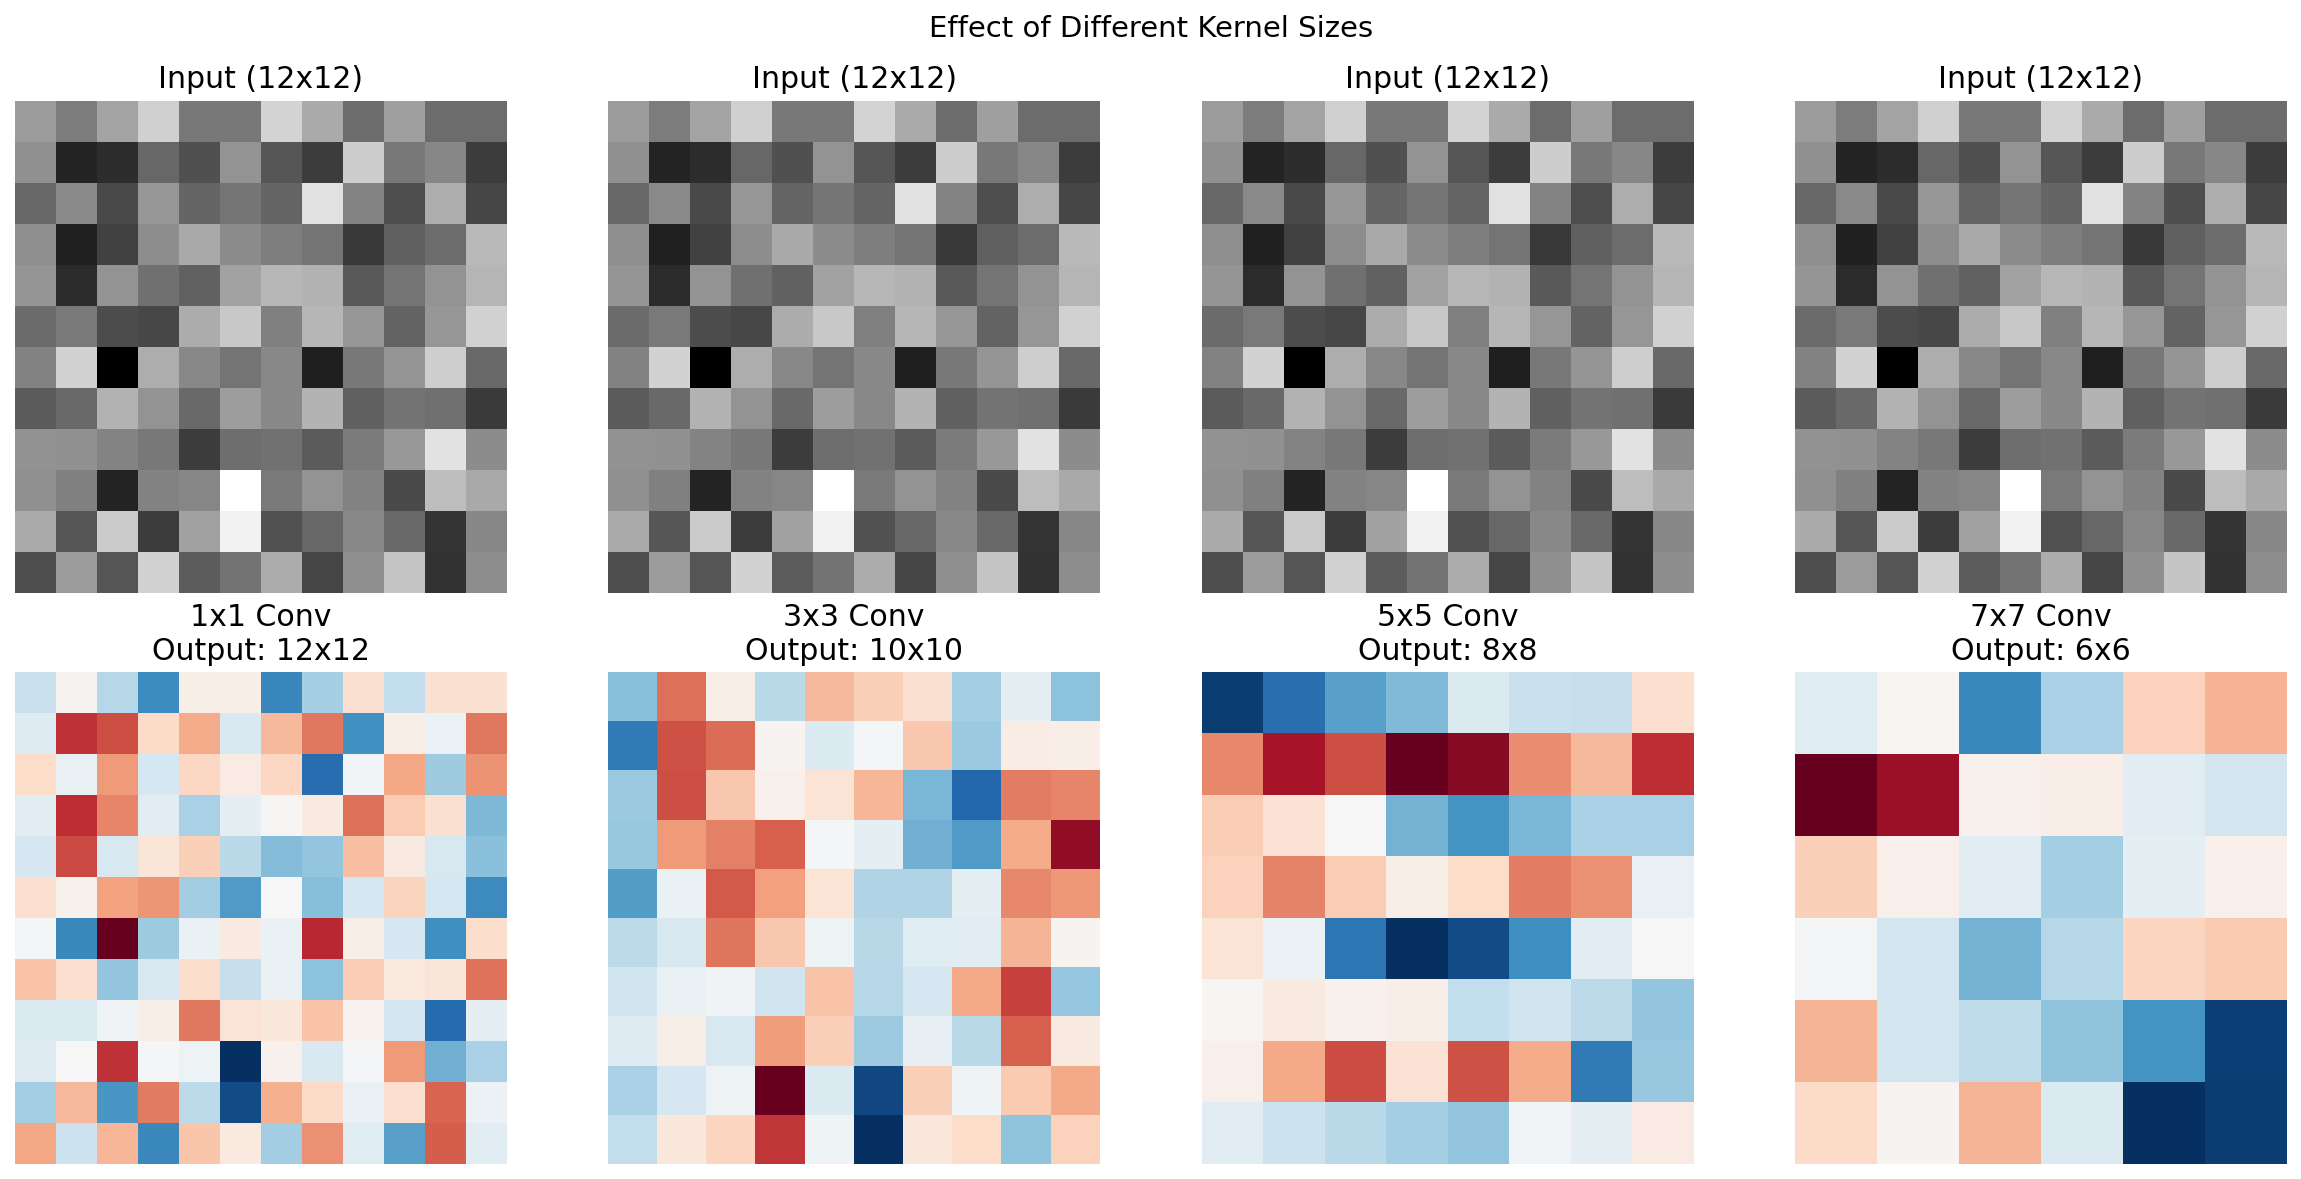

In [36]:
# Compare different kernel sizes
np.random.seed(42)
test_img = np.random.randn(12, 12)

kernels = {
    '1x1': np.array([[1.0]]),
    '3x3': np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]),
    '5x5': np.outer(np.array([1, 0, 0, 0, -1]), np.ones(5)),
    '7x7': np.outer(np.array([1, 1, 0, 0, 0, -1, -1]), np.ones(7)),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, (name, kernel) in enumerate(kernels.items()):
    result = conv2d_general(test_img, kernel, stride=1, padding=0)
    axes[0, idx].imshow(test_img, cmap='gray')
    axes[0, idx].set_title(f'Input (12x12)')
    axes[0, idx].axis('off')
    
    axes[1, idx].imshow(result, cmap='RdBu')
    axes[1, idx].set_title(f'{name} Conv\nOutput: {result.shape[0]}x{result.shape[1]}')
    axes[1, idx].axis('off')

plt.suptitle('Effect of Different Kernel Sizes', fontsize=14)
plt.tight_layout()
plt.savefig('kernel_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as kernel_size_comparison.png")


## 10. 深度与宽度的权衡

### 10.1 网络设计的关键维度

**深度 (Depth):** 网络的层数
- 更深 -> 更大的感受野 -> 能看到更全局的特征
- 更深 -> 更多非线性变换 -> 更强的表达能力
- 问题：梯度消失、训练困难

**宽度 (Width):** 每层的通道数（滤波器数量）
- 更宽 -> 更多特征检测器 -> 能检测更多种特征
- 更宽 -> 更多参数 -> 更大的计算量

**分辨率 (Resolution):** 特征图的空间尺寸
- 通过步长和池化逐步降低分辨率
- 高分辨率 -> 精确的空间定位
- 低分辨率 -> 更全局的感受

### 10.2 经验法则

1. **浅层用小卷积核：** 3x3 是标准选择，计算高效
2. **逐步增加通道数：** 通常每池化一次通道翻倍
3. **分辨率逐步降低：** 通过步长卷积或池化
4. **总参数量控制：** 通过参数共享保持合理


## 11. 实验结果分析

### 关键发现

1. **不同滤波器检测不同特征：** 边缘检测器可以检测水平、垂直、对角线方向的边缘

2. **特征层次性：** 浅层卷积检测简单特征（边缘、角点），深层卷积组合简单特征形成复杂模式

3. **池化提供不变性：** 小的平移在池化后几乎不影响输出，增强了模型的鲁棒性

4. **参数效率：** CNN 通过参数共享大幅减少参数数量，同时保持强大的表达能力

5. **感受野增长：** 多层卷积+池化使深层神经元能"看到"输入图像的更大区域

### CNN vs 全连接网络

| 特性 | 全连接 (MLP) | 卷积 (CNN) |
|------|-------------|-----------|
| 参数数量 | 非常多 | 少（共享） |
| 空间结构 | 丢失 | 保留 |
| 平移不变性 | 无 | 有（通过池化） |
| 适合图像 | 不适合 | 非常适合 |
| 数据需求 | 大量数据 | 相对较少 |


## 12. 经典 CNN 架构简介

### 12.1 LeNet-5 (1998)

LeCun 等人提出的第一个成功的 CNN，用于手写数字识别。
- 架构: Conv -> Pool -> Conv -> Pool -> FC -> FC -> Output
- 输入: 32x32 灰度图像
- 特点: 首次将卷积和池化组合使用

### 12.2 AlexNet (2012)

Krizhevsky 等人在 ImageNet 2012 上取得突破性成绩。
- 架构: 5 卷积层 + 3 全连接层
- 创新: ReLU 激活函数、Dropout、数据增强、GPU 训练
- Top-5 错误率: 15.3%（比第二名低 10.8 个百分点）

### 12.3 VGGNet (2014)

Simonyan & Zisserman 提出的深层网络。
- 核心思想: 使用大量 3x3 小卷积核代替大卷积核
- 架构: 16-19 层，全部使用 3x3 卷积
- 贡献: 证明了深度对性能的重要性

### 12.4 ResNet (2015)

He 等人提出的残差网络。
- 核心创新: 残差连接 (skip connections)
- 架构: 152 层（甚至更深）
- 解决问题: 深度网络的梯度消失
- 影响: 成为现代深度学习的标准组件


## 13. 作业

### 作业 1：实现完整的卷积层前向和反向传播

**要求：**
1. 实现多通道卷积层的前向传播 (conv2d forward)
2. 实现卷积层的反向传播 (conv2d backward)
3. 进行梯度检验 (gradient check)，确保解析梯度与数值梯度一致
4. 在简单的合成数据上训练一个卷积层

**提示：** 卷积的反向传播可以看作"反向卷积" - 将输出梯度用滤波器转置做卷积

### 作业 2：实现 1x1 卷积和空洞卷积 (Dilated Convolution)

**要求：**
1. 实现 1x1 卷积，分析其作用（通道降维/升维）
2. 实现空洞卷积（在滤波器元素间插入间隔），分析其如何扩大感受野
3. 可视化不同膨胀率的感受野大小
4. 比较空洞卷积与普通卷积在相同感受野下的参数数量

**空洞卷积公式：** 滤波器元素间隔为 $d$（膨胀率），等效感受野为 $K + (K-1)(d-1)$

### 作业 3：构建并训练完整的 CNN 分类器

**要求：**
1. 组合 ConvLayer、MaxPoolLayer、FlattenLayer 和 FCLayer 构建完整 CNN
2. 在合成的 2D 图案数据集上训练（如不同形状的分类）
3. 实现 forward 和 backward 传播
4. 可视化训练过程和学习到的特征
5. 分析不同架构（层数、滤波器数量）对性能的影响

**提示：** 使用 generate_spiral_data 的变体，或创建简单的几何形状数据集


## 14. 参考文献

1. **CS231n: Convolutional Neural Networks for Visual Recognition**, Stanford University
   - Lecture 5: Convolutional Neural Networks
   - https://cs231n.github.io/convolutional-networks/

2. **LeCun, Y. et al. (1998)**. Gradient-Based Learning Applied to Document Recognition. Proceedings of the IEEE.

3. **Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012)**. ImageNet Classification with Deep Convolutional Neural Networks. NeurIPS 2012.

4. **Simonyan, K. & Zisserman, A. (2014)**. Very Deep Convolutional Networks for Large-Scale Image Recognition. ICLR 2015.

5. **He, K., Zhang, X., Ren, S., & Sun, J. (2016)**. Deep Residual Learning for Image Recognition. CVPR 2016.

6. **Hubel, D. H. & Wiesel, T. N. (1959)**. Receptive fields of single neurones in the cat's striate cortex. Journal of Physiology.

7. **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. Deep Learning. MIT Press. Chapter 9: Convolutional Networks.

8. **Springenberg, J. T. et al. (2014)**. Striving for Simplicity: The All Convolutional Net. ICLR 2015 Workshop.

9. **Yu, F. & Koltun, V. (2015)**. Multi-Scale Context Aggregation by Dilated Convolutions. ICLR 2016.

10. **Lin, M., Chen, Q., & Yan, S. (2013)**. Network In Network. arXiv:1312.4400.

---

**本 notebook 总结：**
- CNN 通过局部连接和参数共享大幅减少参数数量
- 卷积操作在输入上滑动滤波器，计算局部特征
- 池化层进行下采样，提供平移不变性
- 多层卷积+池化构建特征层次：从边缘到纹理到物体
- 感受野随网络深度增长，深层神经元"看到"更大的输入区域
- 3x3 小卷积核优于大卷积核：参数少、非线性强、感受野等效
- 经典架构: LeNet -> AlexNet -> VGG -> ResNet，不断加深加宽


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[Skylark0924/Machine-Learning-is-ALL-You-Need](https://github.com/Skylark0924/Machine-Learning-is-ALL-You-Need)** (424 stars): CNN 从零实现（numpy）
  - 仓库地址: https://github.com/Skylark0924/Machine-Learning-is-ALL-You-Need

- **[MorvanZhou/PyTorch-Tutorial](https://github.com/MorvanZhou/PyTorch-Tutorial)** (8466 stars): CNN PyTorch 教程（含中文注释）
  - 仓库地址: https://github.com/MorvanZhou/PyTorch-Tutorial


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

